In [44]:
df_train = pd.read_csv('data/transactions_train.csv')
df_test = pd.read_csv('data/transactions_test.csv')

In [45]:
# Drop IDs (no predictive value)
drop_cols = ['transaction_id', 'customer_id', 'merchant_id']
df_train = df_train.drop(columns=drop_cols)
df_test = df_test.drop(columns=drop_cols)

In [46]:
df_train['transaction_time'] = pd.to_datetime(df_train['transaction_time'])
df_test['transaction_time'] = pd.to_datetime(df_test['transaction_time'])

# Extract useful features
for df in [df_train, df_test]:
    df['hour'] = df['transaction_time'].dt.hour
    df['day'] = df['transaction_time'].dt.dayofweek

# Drop original
df_train = df_train.drop(columns=['transaction_time'])
df_test = df_test.drop(columns=['transaction_time'])

In [47]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['payment_channel', 'device_type']

for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([df_train[col], df_test[col]]).astype(str)
    le.fit(combined)
    
    df_train[col] = le.transform(df_train[col].astype(str))
    df_test[col] = le.transform(df_test[col].astype(str))

In [48]:
X_train = df_train.drop('is_fraud', axis=1)
y_train = df_train['is_fraud']

X_test = df_test.drop('is_fraud', axis=1)
y_test = df_test['is_fraud']

In [49]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print("Scale pos weight:", scale_pos_weight)

Scale pos weight: 60.61219462122767


In [50]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [51]:
y_prob = model.predict_proba(X_test)[:, 1]

# Slightly aggressive threshold
threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

In [52]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     97904
           1       0.98      0.98      0.98      1983

    accuracy                           1.00     99887
   macro avg       0.99      0.99      0.99     99887
weighted avg       1.00      1.00      1.00     99887

[[97862    42]
 [   30  1953]]
ROC-AUC: 0.9999729272603697


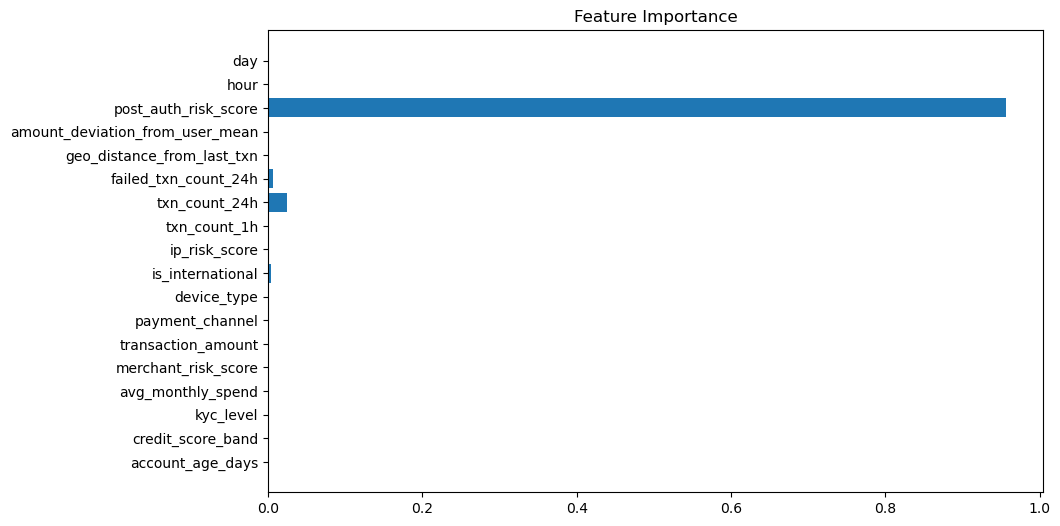

In [53]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

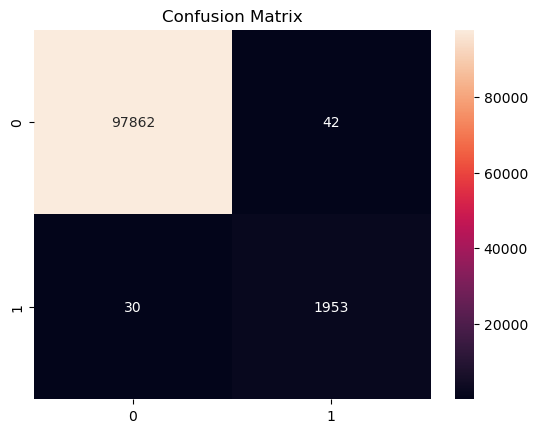

In [54]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

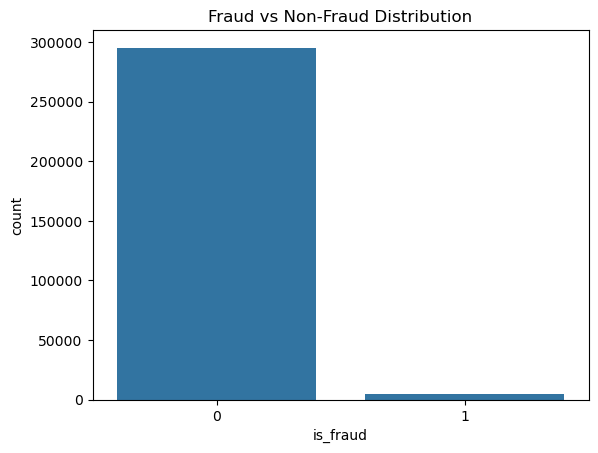

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

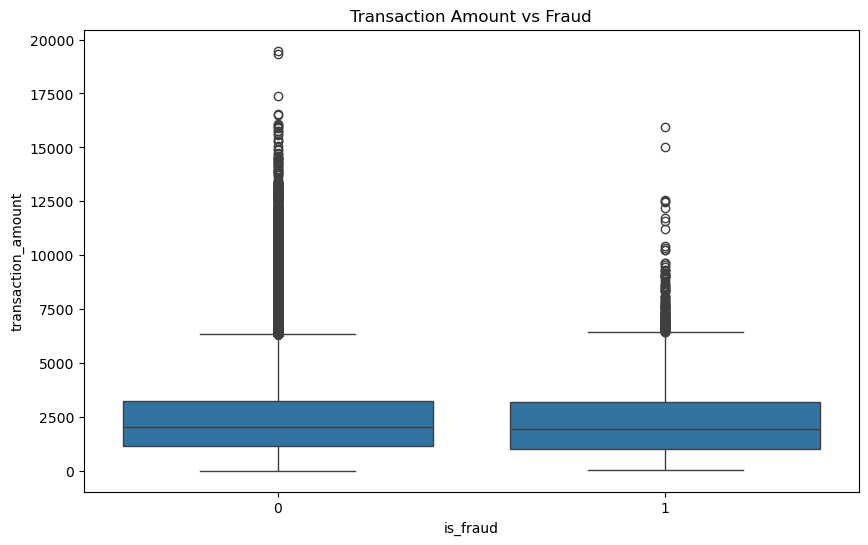

In [56]:
plt.figure(figsize=(10,6))
sns.boxplot(x=y_train, y=X_train['transaction_amount'])
plt.title("Transaction Amount vs Fraud")
plt.show()

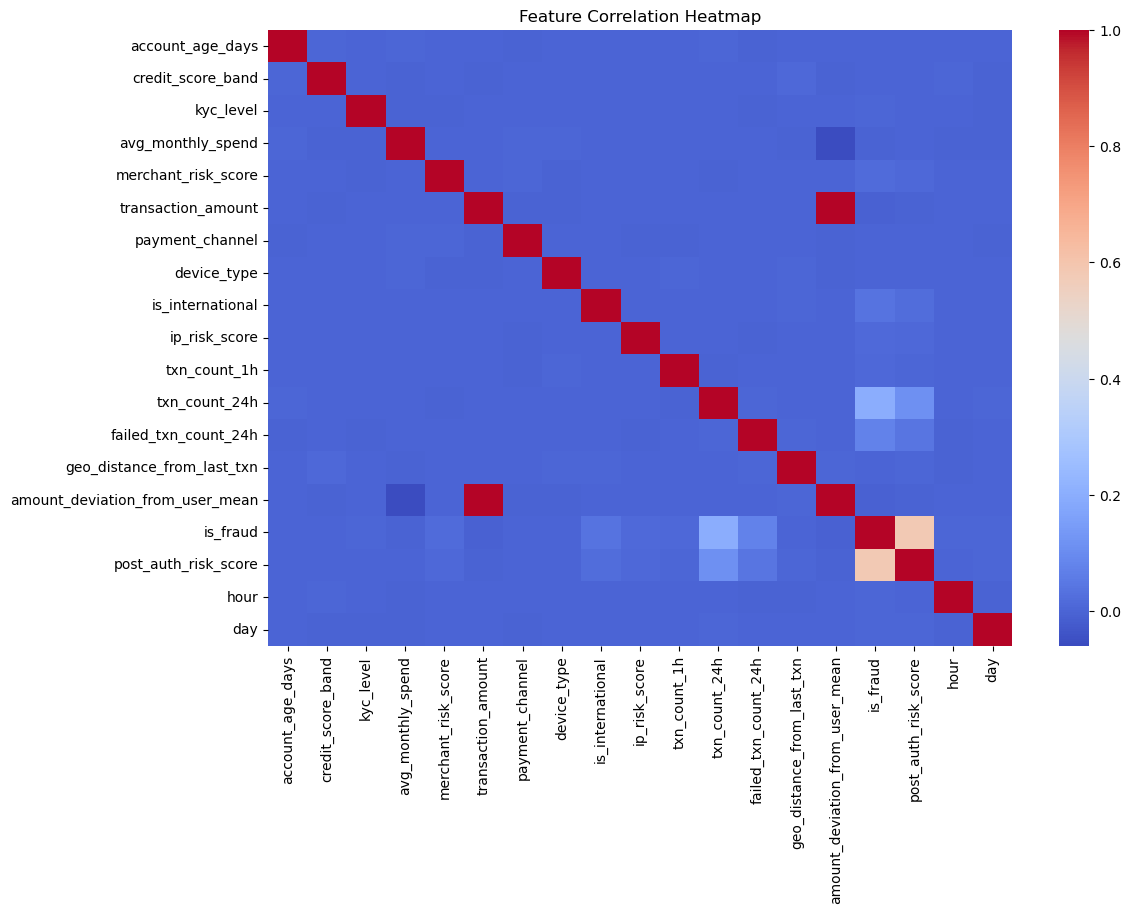

In [57]:
plt.figure(figsize=(12,8))
sns.heatmap(df_train.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

C:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


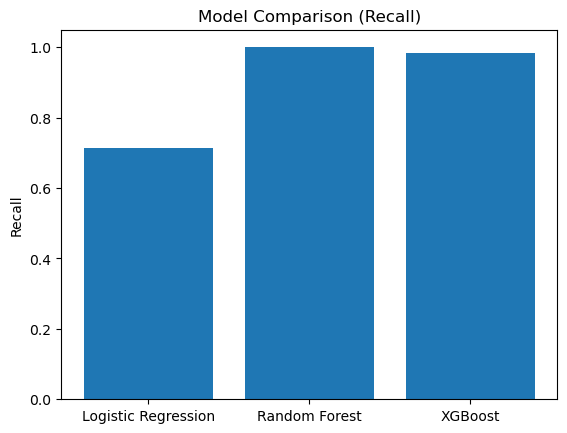

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": model
}

results = {}

for name, m in models.items():
    if name != "XGBoost":
        m.fit(X_train, y_train)
        y_pred_temp = m.predict(X_test)
    else:
        y_pred_temp = y_pred
    
    from sklearn.metrics import recall_score
    results[name] = recall_score(y_test, y_pred_temp)

# Plot
plt.bar(results.keys(), results.values())
plt.title("Model Comparison (Recall)")
plt.ylabel("Recall")
plt.show()

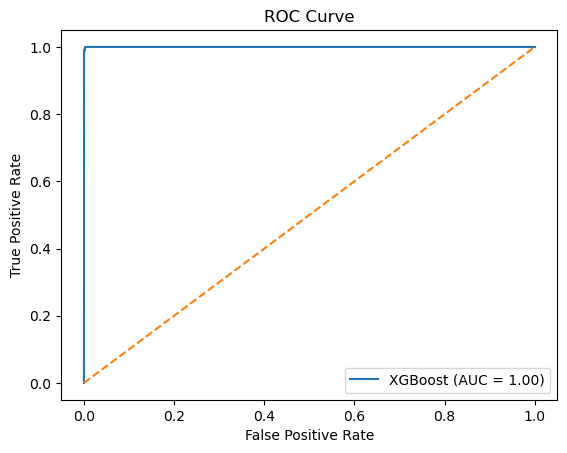

In [62]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

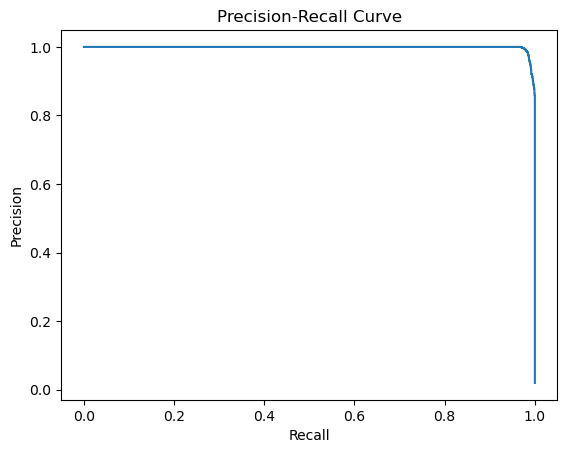

In [63]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

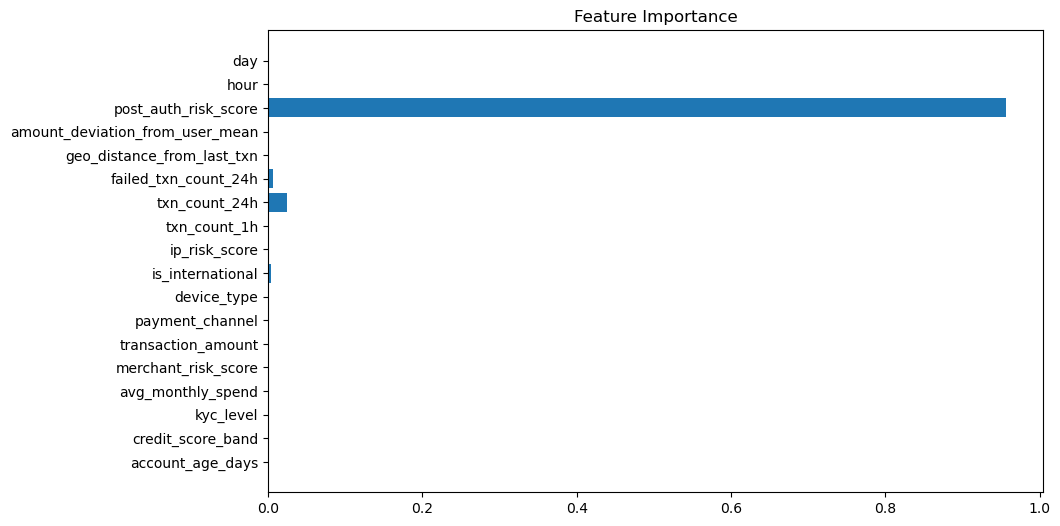

In [64]:
importances = model.feature_importances_
features = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()